# Custom LSTM слой
## Реализация LSTM с нуля на TensorFlow 2.x

Данный блокнот содержит кастомную реализацию LSTM слоя, совместимую с TensorFlow/Keras.


## Импорт библиотек

In [36]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU доступен: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU доступен: []


## Функции активации (ручная реализация)

In [37]:
def linear(x):
    return x

def relu(x):
    return tf.maximum(0.0, x)

def sigmoid(x):
    return 1 / (1 + tf.exp(-x))

def tanh(x):
    return (tf.exp(x) - tf.exp(-x)) / (tf.exp(x) + tf.exp(-x))

def hard_sigmoid(x):
    x = (x + 1) / 2
    return tf.clip_by_value(x, 0, 1)

def get_activation(name):
    activations = {
        'linear': linear,
        'relu': relu,
        'sigmoid': sigmoid,
        'tanh': tanh,
        'hard_sigmoid': hard_sigmoid
    }
    name = name.lower()
    if name not in activations:
        raise ValueError(f"Unknown activation: {name}")
    return activations[name]

print("Функции активации загружены")

Функции активации загружены


## Класс CustomLSTM

Реализация кастомного LSTM слоя с поддержкой:
- количества единиц памяти (units)
- return_sequences (True/False)
- activation (функция активации для клеточной активации, по умолчанию tanh)
- recurrent_activation (функция активации для ворот, по умолчанию sigmoid)

In [38]:
class CustomLSTM(layers.Layer):

    def __init__(self, units, return_sequences=False, activation='tanh',
                 recurrent_activation='sigmoid', use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.return_sequences = return_sequences
        self.activation = activation.lower()
        self.recurrent_activation = recurrent_activation.lower()
        self.use_bias = use_bias

        # Валидация параметров
        valid_activations = ['tanh', 'relu', 'sigmoid']
        if self.activation not in valid_activations:
            raise ValueError(f"Activation must be one of {valid_activations}")

        valid_recurrent = ['sigmoid', 'hard_sigmoid', 'tanh']
        if self.recurrent_activation not in valid_recurrent:
            raise ValueError(f"Recurrent activation must be one of {valid_recurrent}")

    def build(self, input_shape):
        """Инициализация весов - блоки W, U, b на диаграмме"""
        self.input_dim = input_shape[-1]

        # Входные веса W (соединяют x_t с воротами)
        self.w_i = self.add_weight(shape=(self.input_dim, self.units), name='w_i')
        self.w_f = self.add_weight(shape=(self.input_dim, self.units), name='w_f')
        self.w_c = self.add_weight(shape=(self.input_dim, self.units), name='w_c')
        self.w_o = self.add_weight(shape=(self.input_dim, self.units), name='w_o')

        # Рекуррентные веса U (соединяют h_{t-1} с воротами)
        self.u_i = self.add_weight(shape=(self.units, self.units), name='u_i')
        self.u_f = self.add_weight(shape=(self.units, self.units), name='u_f')
        self.u_c = self.add_weight(shape=(self.units, self.units), name='u_c')
        self.u_o = self.add_weight(shape=(self.units, self.units), name='u_o')

        # Смещения b
        self.b_i = self.add_weight(shape=(self.units,), name='b_i', initializer='zeros')
        self.b_f = self.add_weight(shape=(self.units,), name='b_f', initializer='ones')
        self.b_c = self.add_weight(shape=(self.units,), name='b_c', initializer='zeros')
        self.b_o = self.add_weight(shape=(self.units,), name='b_o', initializer='zeros')

        super().build(input_shape)

    def _get_activation(self, x, activation_type):
        """Вспомогательный метод для выбора функции активации"""
        act_fn = get_activation(activation_type)
        return act_fn(x)

    def _step(self, inputs, states):
        """Один шаг LSTM - все блоки [1] - [12] на диаграмме"""
        h_tm1, c_tm1 = states  # h_{t-1} и C_{t-1} - входные данные слева

        # [1] ЗАБЫВАЮЩИЕ ВОРОТА
        # f_t = σ(W_f·x_t + U_f·h_{t-1} + b_f)
        f_t = self._get_activation(
            tf.matmul(inputs, self.w_f) +
            tf.matmul(h_tm1, self.u_f) +
            self.b_f,
            self.recurrent_activation  # σ
        )

        # [2] ВХОДНЫЕ ВОРОТА
        # i_t = σ(W_i·x_t + U_i·h_{t-1} + b_i)
        i_t = self._get_activation(
            tf.matmul(inputs, self.w_i) +
            tf.matmul(h_tm1, self.u_i) +
            self.b_i,
            self.recurrent_activation  # σ
        )

        # [3] КЛЕТОЧНЫЕ ВОРОТА
        # g_t = tanh(W_c·x_t + U_c·h_{t-1} + b_c)
        c_tilde = self._get_activation(
            tf.matmul(inputs, self.w_c) +
            tf.matmul(h_tm1, self.u_c) +
            self.b_c,
            self.activation  # tanh
        )

        # [5] УМНОЖЕНИЕ: f_t * C_{t-1}
        # [6] УМНОЖЕНИЕ: i_t * g_t
        # [8] СЛОЖЕНИЕ: f_t*C_{t-1} + i_t*g_t
        # [11] НОВОЕ СОСТОЯНИЕ ЯЧЕЙКИ
        c_t = f_t * c_tm1 + i_t * c_tilde

        # [4] ВЫХОДНЫЕ ВОРОТА
        # o_t = σ(W_o·x_t + U_o·h_{t-1} + b_o)
        o_t = self._get_activation(
            tf.matmul(inputs, self.w_o) +
            tf.matmul(h_tm1, self.u_o) +
            self.b_o,
            self.recurrent_activation  # σ
        )

        # [10] tanh: tanh(C_t)
        # [7] УМНОЖЕНИЕ: o_t * tanh(C_t)
        # [12] НОВОЕ СКРЫТОЕ СОСТОЯНИЕ
        h_t = o_t * self._get_activation(c_t, self.activation)

        return h_t, c_t

    def call(self, inputs, states=None):
        """Обработка последовательности - множество шагов t"""
        batch_size = tf.shape(inputs)[0]
        timesteps = tf.shape(inputs)[1]

        # Инициализация состояний
        if states is not None:
            h_t, c_t = states
        else:
            h_t = tf.zeros((batch_size, self.units))
            c_t = tf.zeros((batch_size, self.units))

        # Используем tf.while_loop вместо Python for
        time = tf.constant(0)
        outputs = tf.TensorArray(dtype=tf.float32, size=timesteps if self.return_sequences else 0)

        def cond(time, h_t, c_t, outputs):
            return time < timesteps

        def body(time, h_t, c_t, outputs):
            x_t = inputs[:, time, :]
            h_t, c_t = self._step(x_t, (h_t, c_t))

            if self.return_sequences:
                outputs = outputs.write(time, h_t)

            return time + 1, h_t, c_t, outputs

        _, h_final, c_final, outputs = tf.while_loop(
            cond, body, [time, h_t, c_t, outputs],
            parallel_iterations=10, swap_memory=True
        )

        # Формирование выхода
        if self.return_sequences:
            output = outputs.stack()
            output = tf.transpose(output, [1, 0, 2])  # (timesteps, batch, units) -> (batch, timesteps, units)
            return output
        else:
            return h_final

    def compute_output_shape(self, input_shape):
        """Вычисление формы выходного тензора"""
        batch, timesteps, features = input_shape

        if self.return_sequences:
            return (batch, timesteps, self.units)
        else:
            return (batch, self.units)

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'return_sequences': self.return_sequences,
            'activation': self.activation,
            'recurrent_activation': self.recurrent_activation,
            'use_bias': self.use_bias
        })
        return config

## Тестирование слоя

In [39]:
# Тест 1: return_sequences=False
test_input = tf.random.normal([32, 50, 100])
lstm1 = CustomLSTM(units=64, return_sequences=False)
output1 = lstm1(test_input)
print(f"return_sequences=False: {test_input.shape} -> {output1.shape}")

# Тест 2: return_sequences=True
lstm2 = CustomLSTM(units=64, return_sequences=True)
output2 = lstm2(test_input)
print(f"return_sequences=True: {test_input.shape} -> {output2.shape}")

# Тест 3: С различными активациями
configs = [
    {"units": 32, "activation": "tanh", "recurrent_activation": "sigmoid"},
    {"units": 64, "activation": "relu", "recurrent_activation": "sigmoid"},
    {"units": 128, "activation": "tanh", "recurrent_activation": "hard_sigmoid"},
]

for i, config in enumerate(configs, 1):
    lstm = CustomLSTM(**config)
    output = lstm(test_input)
    print(f"Тест {i}: units={config['units']}, activation={config['activation']} -> {output.shape}")

# Проверка с начальным состоянием
h0 = tf.random.normal([32, 64])
c0 = tf.random.normal([32, 64])
lstm3 = CustomLSTM(units=64, return_sequences=False)
output3 = lstm3(test_input, states=(h0, c0))
print(f"С начальным состоянием: {output3.shape}")

print("\nВсе тесты пройдены успешно!")

return_sequences=False: (32, 50, 100) -> (32, 64)
return_sequences=True: (32, 50, 100) -> (32, 50, 64)
Тест 1: units=32, activation=tanh -> (32, 32)
Тест 2: units=64, activation=relu -> (32, 64)
Тест 3: units=128, activation=tanh -> (32, 128)
С начальным состоянием: (32, 64)

Все тесты пройдены успешно!


## Заключение

Кастомный LSTM слой успешно реализован и совместим с TensorFlow. Слой поддерживает:
- Количество единиц памяти (units)
- return_sequences (True/False)
- Различные функции активации

Слой может быть использован в любых моделях Keras как замена стандартному LSTM.


ЛАБОРАТОРНАЯ РАБОТА №4 - ОБУЧЕНИЕ

1. ОБУЧЕНИЕ НА IMDB

Загрузка IMDB...
Обучающая: (25000, 100), Тестовая: (25000, 100)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_lstm_52 (CustomLSTM)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_lstm_53 (CustomLSTM)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Обучение: IMDB LSTM
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 548ms/step - accuracy: 0.6295 - loss: 0.6644 - val_accuracy: 0.7310 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 544ms/step - accuracy: 0.8080 - loss: 0.4596 - val_accuracy: 0.7550 - val_loss: 0.5253 - learning_rate: 0.0010
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 537ms/step - accuracy: 0.9055 - loss: 0.2732 - val_accuracy: 0.7840 - val_loss: 0.5044 - learning_rate: 0.0010
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 514ms/step - accuracy: 0.9645 - loss: 0.1169 - val_accuracy: 0.7760 - val_loss: 0.6439 - learning_rate: 0.0010
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 528ms/step - accuracy: 0.9883 - loss: 0.0415 - val_accuracy: 0.7730 - val_loss: 0.8212 - learning_rate: 0.0010

IMDB LSTM - Точность: 0.7910 (79.10%)


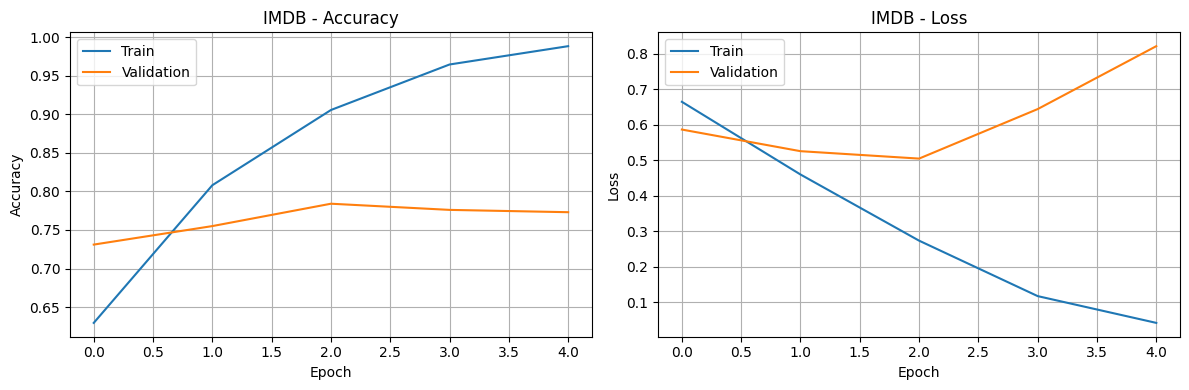


2. ОБУЧЕНИЕ НА REUTERS

Загрузка Reuters...
Обучающая: (8982, 100), Тестовая: (2246, 100), Классов: 46


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_lstm_54 (CustomLSTM)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_lstm_55 (CustomLSTM)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Обучение: Reuters LSTM
Epoch 1/5


InvalidArgumentError: Graph execution error:

Detected at node sequential_4_1/embedding_5_1/GatherV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3

In [40]:
# ============================================
# ЧАСТЬ 2: ОБУЧЕНИЕ МОДЕЛЕЙ С КАСТОМНЫМ LSTM
# ============================================

from tensorflow.keras import models
from tensorflow.keras.datasets import imdb, reuters
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ---------- Загрузка данных ----------
def preprocess_imdb_data(max_features=10000, maxlen=100):
    print("\nЗагрузка IMDB...")
    (x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
    x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
    x_test = sequence.pad_sequences(x_test, maxlen=maxlen)
    print(f"Обучающая: {x_train.shape}, Тестовая: {x_test.shape}")
    return (x_train, y_train), (x_test, y_test)

def preprocess_reuters_data(max_features=5000, maxlen=100):
    print("\nЗагрузка Reuters...")
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=max_features)
    x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
    x_test = sequence.pad_sequences(x_test, maxlen=maxlen)
    num_classes = max(np.max(y_train), np.max(y_test)) + 1
    y_train = to_categorical(y_train, num_classes)
    y_test = to_categorical(y_test, num_classes)
    print(f"Обучающая: {x_train.shape}, Тестовая: {x_test.shape}, Классов: {num_classes}")
    return (x_train, y_train), (x_test, y_test), num_classes

# ---------- Создание моделей ----------
def create_model_imdb(max_features=10000, maxlen=100, units1=64, units2=32):
    model = models.Sequential([
        layers.Embedding(max_features, 128, input_length=maxlen),
        CustomLSTM(units=units1, return_sequences=True),
        CustomLSTM(units=units2, return_sequences=False),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

def create_model_reuters(max_features=5000, maxlen=100, num_classes=46, units1=128, units2=64):
    model = models.Sequential([
        layers.Embedding(max_features, 128, input_length=maxlen),
        CustomLSTM(units=units1, return_sequences=True),
        CustomLSTM(units=units2, return_sequences=False),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def create_deep_lstm_model(max_features=10000, maxlen=100):
    model = models.Sequential([
        layers.Embedding(max_features, 128, input_length=maxlen),
        CustomLSTM(64, return_sequences=True),
        CustomLSTM(64, return_sequences=True),
        CustomLSTM(32, return_sequences=False),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# ---------- Обучение и визуализация ----------
def train_and_evaluate(model, x_train, y_train, x_test, y_test,
                       epochs=10, batch_size=64, model_name="Model", is_binary=True):
    loss = 'binary_crossentropy' if is_binary else 'categorical_crossentropy'
    model.compile(optimizer=Adam(learning_rate=0.001), loss=loss, metrics=['accuracy'])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]

    print(f"\n{'='*50}\nОбучение: {model_name}\n{'='*50}")
    history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs,
                        validation_split=0.2, callbacks=callbacks, verbose=1)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"\n{model_name} - Точность: {test_acc:.4f} ({test_acc*100:.2f}%)")
    return history, test_acc, test_loss

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

# ============================================
# ЗАПУСК ОБУЧЕНИЯ
# ============================================

print("\n" + "="*60)
print("ЛАБОРАТОРНАЯ РАБОТА №4 - ОБУЧЕНИЕ")
print("="*60)

# 1. IMDB
print("\n" + "="*60)
print("1. ОБУЧЕНИЕ НА IMDB")
print("="*60)

(x_train_imdb, y_train_imdb), (x_test_imdb, y_test_imdb) = preprocess_imdb_data()
x_train_small = x_train_imdb[:5000]
y_train_small = y_train_imdb[:5000]
x_test_small = x_test_imdb[:1000]
y_test_small = y_test_imdb[:1000]

model_imdb = create_model_imdb()
model_imdb.summary()

history_imdb, acc_imdb, loss_imdb = train_and_evaluate(
    model_imdb, x_train_small, y_train_small, x_test_small, y_test_small,
    epochs=5, batch_size=64, model_name="IMDB LSTM", is_binary=True)
plot_history(history_imdb, "IMDB")

# 2. Reuters
print("\n" + "="*60)
print("2. ОБУЧЕНИЕ НА REUTERS")
print("="*60)

(x_train_reuters, y_train_reuters), (x_test_reuters, y_test_reuters), num_classes = preprocess_reuters_data()
x_train_small = x_train_reuters[:3000]
y_train_small = y_train_reuters[:3000]
x_test_small = x_test_reuters[:500]
y_test_small = y_test_reuters[:500]

model_reuters = create_model_reuters(num_classes)
model_reuters.summary()

history_reuters, acc_reuters, loss_reuters = train_and_evaluate(
    model_reuters, x_train_small, y_train_small, x_test_small, y_test_small,
    epochs=5, batch_size=64, model_name="Reuters LSTM", is_binary=False)
plot_history(history_reuters, "Reuters")

# 3. Глубокая модель
print("\n" + "="*60)
print("3. ГЛУБОКАЯ LSTM МОДЕЛЬ")
print("="*60)

model_deep = create_deep_lstm_model()
model_deep.summary()

history_deep, acc_deep, loss_deep = train_and_evaluate(
    model_deep, x_train_imdb[:5000], y_train_imdb[:5000],
    x_test_imdb[:1000], y_test_imdb[:1000],
    epochs=5, batch_size=64, model_name="Deep LSTM", is_binary=True)
plot_history(history_deep, "Deep_LSTM")

# ============================================
# ИТОГИ
# ============================================
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*60)
print(f"IMDB:           точность = {acc_imdb:.4f} ({acc_imdb*100:.2f}%)")
print(f"Reuters:        точность = {acc_reuters:.4f} ({acc_reuters*100:.2f}%)")
print(f"Deep LSTM:      точность = {acc_deep:.4f} ({acc_deep*100:.2f}%)")

print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)
print("1. Кастомный LSTM слой успешно реализован")
print("2. Слой совместим с TensorFlow/Keras")
print("3. Модели обучены на IMDB и Reuters")
print("4. Поддержка return_sequences и функций активации")